# DEVOIR – CNN “from scratch” vs Transfert Learning (Cats vs Dogs)

## Objectif

Comparer **un modèle CNN entraîné from scratch** et **un modèle en transfert d’apprentissage** sur le même jeu de données (cats vs dogs). Montrer l’impact du transfert learning sur la convergence, la performance et la robustesse.

# 01. Imports

In [1]:

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm.auto import tqdm
import pandas as pd
import openpyxl

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

import my_helper

# configuration des repertoires

In [2]:
import os

BASE_DIR = os.getcwd()

DATA_DIR = os.path.join(BASE_DIR, "data")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


print("Projet :", BASE_DIR)
print("Données :", DATA_DIR)
print("Checkpoints :", CHECKPOINT_DIR)
print("Figures :", FIGURES_DIR)

Projet : c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\cnn-catsdogs-DrameSekou
Données : c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\cnn-catsdogs-DrameSekou\data
Checkpoints : checkpoints
Figures : c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\cnn-catsdogs-DrameSekou\figures


# 02. Fixation du seed et configuration du  Device

In [3]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)

Device utilisé : cpu


In [4]:
data_dir = DATA_DIR+"/train"

#transform = # TODO: compose transforms here
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

#dataset = # TODO: create the ImageFolder
dataset = datasets.ImageFolder(data_dir, transform=transform)

#dataloader = # TODO: use the ImageFolder dataset to create the DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

<Axes: >

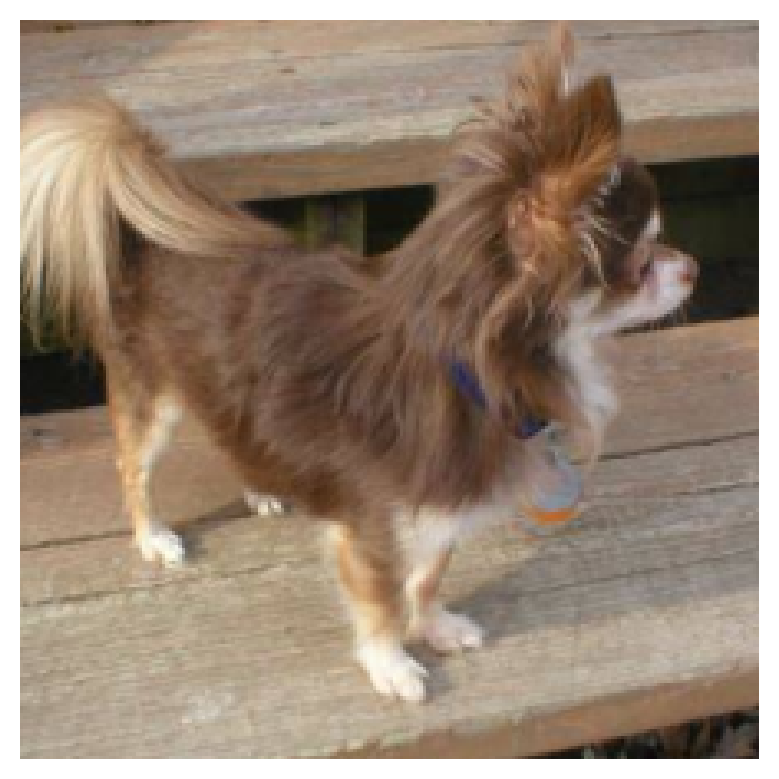

In [6]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0], normalize=False)

Si vous avez correctement chargé les données, vous devriez obtenir un affichage similaire à celui-ci (votre image sera différente) :




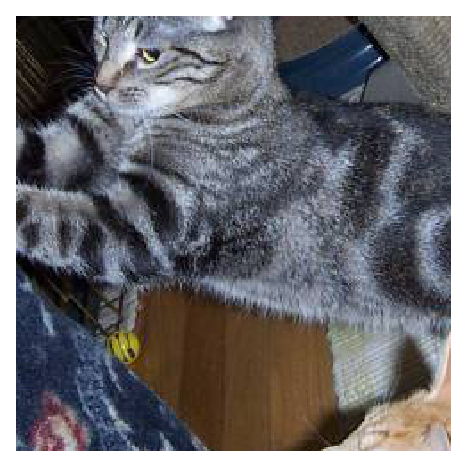


## Augmentation de Données

Une stratégie courante pour entraîner des réseaux de neurones consiste à introduire une **certaine forme d’aléatoire dans les données d’entrée**.  
Par exemple, on peut faire tourner, refléter, redimensionner et/ou rogner aléatoirement les images pendant l’entraînement.  
Cela aide le réseau à **mieux généraliser**, car il voit les mêmes images sous différentes formes : positions, tailles, orientations, etc.

Pour appliquer une rotation, un recadrage et un redimensionnement aléatoires, puis retourner les images horizontalement, on peut définir les transformations ainsi :

```python
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])
````

Il est également recommandé de **normaliser les images** à l’aide de `transforms.Normalize`.
Cette transformation prend en entrée :

* une liste de **moyennes** (`mean`)
* et une liste d’**écarts-types** (`std`)

Chaque canal de couleur est alors normalisé selon la formule :

```
input[channel] = (input[channel] - mean[channel]) / std[channel]
```

Soustraire la moyenne recentre les données autour de zéro,
et diviser par l’écart-type comprime les valeurs entre **-1 et 1**.
Cette normalisation aide à maintenir les **poids du réseau proches de zéro**,
rendant ainsi la **rétropropagation plus stable**.
Sans normalisation, le réseau risque souvent d’échouer à apprendre correctement.

Vous pouvez consulter la **liste complète des transformations disponibles** [ici](http://pytorch.org/docs/0.3.0/torchvision/transforms.html).

Lors des phases de **validation** ou de **test**, on utilise généralement des images **non altérées** (hormis la normalisation).
Ainsi, pour les données de validation ou de test, on se contente en général de **redimensionner** et **recadrer** les images.

---

> **Exercice :**
> Définissez ci-dessous les **transformations** pour les données d’entraînement et de test.
> Ne mettez pas encore la normalisation.

```



# chargement, transformation et split (train, validation, test) 

In [6]:
data_dir = DATA_DIR

# ============================================================
# TRANSFORMATIONS
# ============================================================

# Transformations appliquées aux images d'entraînement
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

# Transformations appliquées à la validation et au test
# Aucune augmentation aléatoire
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# ============================================================
# DATASETS
# ============================
# ================================

# Dataset d'entraînement avec augmentation
full_train_aug = datasets.ImageFolder(
    data_dir + "/train",
    transform=train_transforms
)

# Même dataset, mais sans augmentation
# Utilisé pour créer la validation
full_train_eval = datasets.ImageFolder(
    data_dir + "/train",
    transform=val_test_transforms
)

# Dataset de test
test_data = datasets.ImageFolder(
    data_dir + "/test",
    transform=val_test_transforms
)


# ============================================================
# SPLIT TRAIN / VALIDATION
# ============================================================

# 80 % train
train_size = int(0.8 * len(full_train_aug))

# 20 % validation
val_size = len(full_train_aug) - train_size

# Générateur reproductible
split_generator = torch.Generator().manual_seed(SEED)

# Mélange reproductible des indices
indices = torch.randperm(
    len(full_train_aug),
    generator=split_generator
)

# Indices du train
train_indices = indices[:train_size]

# Indices de validation
val_indices = indices[train_size:]


# ============================================================
# SOUS-DATASETS
# ============================================================

# Train avec augmentation
train_data = torch.utils.data.Subset(
    full_train_aug,
    train_indices
)

# Validation sans augmentation
val_data = torch.utils.data.Subset(
    full_train_eval,
    val_indices
)


# ============================================================
# DATALOADERS
# ============================================================

# Générateur pour rendre le shuffle du train reproductible
train_generator = torch.Generator().manual_seed(SEED)

trainloader = torch.utils.data.DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    generator=train_generator,
    pin_memory=True
)

# Pas de shuffle pour la validation
valloader = torch.utils.data.DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

# Pas de shuffle pour le test
testloader = torch.utils.data.DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,
    pin_memory=True
    
)


# ============================================================
# VERIFICATION
# ============================================================

print("Nombre total train :", len(full_train_aug))
print("Nombre train       :", len(train_data))
print("Nombre validation  :", len(val_data))
print("Nombre test        :", len(test_data))
print("Classes            :", full_train_aug.classes)

Nombre total train : 22500
Nombre train       : 18000
Nombre validation  : 4500
Nombre test        : 2500
Classes            : ['cat', 'dog']


In [7]:
print("Nombre d'images train :", len(train_data))
print("Nombre d'images validation :", len(val_data))
print("Nombre d'images test :", len(test_data))

Nombre d'images train : 18000
Nombre d'images validation : 4500
Nombre d'images test : 2500


In [8]:
print("Classes :", train_data.dataset.classes if hasattr(train_data, "dataset") else train_data.classes)

Classes : ['cat', 'dog']


In [9]:
# change this to the trainloader or testloader
data_iter = iter(trainloader)

c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [10]:
images, labels = next(data_iter)
labels

tensor([1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
        1, 1, 0, 0, 1, 0, 1, 0])

tensor([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 0, 0])
tensor([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 0, 0])
tensor([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 0, 0])
tensor([1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 0, 0])


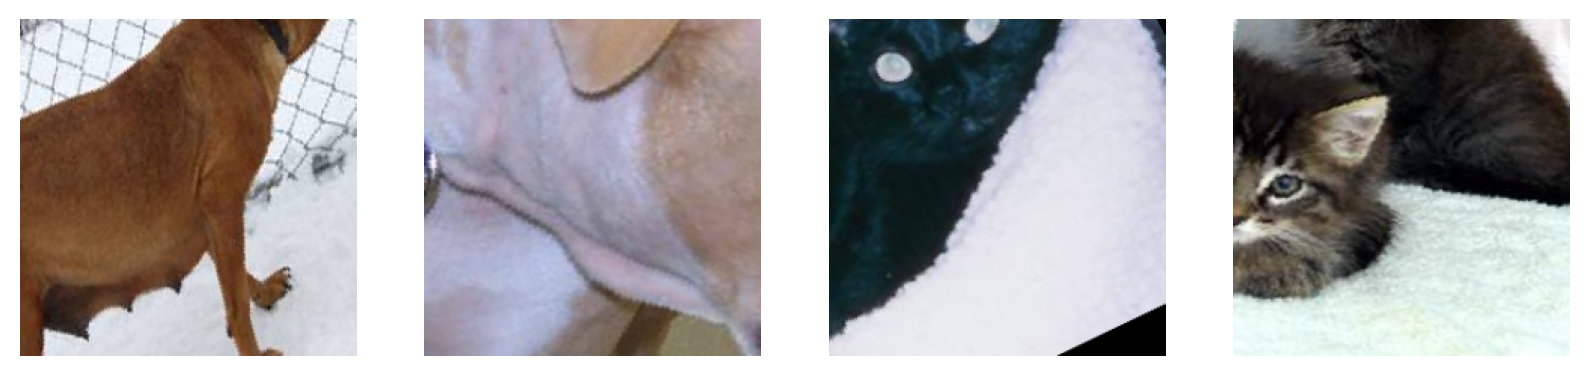

In [11]:
images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    print(labels)
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=False)

Vos images transformées devraient ressembler à quelque chose comme ceci.





À ce stade, vous devriez être en mesure de charger les données pour l’entraînement et le test.  
Vous pouvez maintenant essayer de construire un réseau capable de **classer les chats et les chiens**.



In [12]:
images.shape

torch.Size([32, 3, 224, 224])

# contruction modéle CNN

In [14]:
class ScratchCNN(nn.Module):

    def __init__(self, n_classes=2):
        super().__init__()

        # Bloc 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # 3 canaux RGB → 32 cartes de caractéristiques
        self.bn1 = nn.BatchNorm2d(32)                             # Normalise les 32 cartes de caractéristiques
        self.pool1 = nn.MaxPool2d(2, 2)                           # Divise hauteur et largeur par 2

        # Bloc 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 → 64 cartes de caractéristiques
        self.bn2 = nn.BatchNorm2d(64)                             # Normalise les 64 cartes
        self.pool2 = nn.MaxPool2d(2, 2)                           # Divise encore les dimensions par 2

        # Bloc 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64 → 128 cartes de caractéristiques
        self.bn3 = nn.BatchNorm2d(128)                             # Normalise les 128 cartes
        self.pool3 = nn.MaxPool2d(2, 2)                            # Divise encore les dimensions par 2

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))           # Transforme 128×28×28 en 128×1×1

        self.fc1 = nn.Linear(128, 256)                            # 128 caractéristiques → 256 neurones

        self.dropout = nn.Dropout(0.5)                            # Désactive aléatoirement 50 % des neurones

        self.fc2 = nn.Linear(256, n_classes)                      # 256 neurones → 2 classes

    def forward(self, x):

        x = self.conv1(x)                                         # Application de la première convolution
        x = self.bn1(x)                                           # Normalisation
        x = F.relu(x)                                             # Fonction d'activation ReLU
        x = self.pool1(x)                                         # Réduction de la taille

        x = self.conv2(x)                                         # Application de la deuxième convolution
        x = self.bn2(x)                                           # Normalisation
        x = F.relu(x)                                             # Fonction d'activation ReLU
        x = self.pool2(x)                                         # Réduction de la taille

        x = self.conv3(x)                                         # Application de la troisième convolution
        x = self.bn3(x)                                           # Normalisation
        x = F.relu(x)                                             # Fonction d'activation ReLU
        x = self.pool3(x)                                         # Réduction de la taille

        x = self.global_pool(x)                                   # Réduction de chaque carte à une seule valeur

        x = torch.flatten(x, start_dim=1)                         # Passage de [batch, 128, 1, 1] à [batch, 128]

        x = self.fc1(x)                                           # Première couche entièrement connectée
        x = F.relu(x)                                             # Activation ReLU

        x = self.dropout(x)                                       # Régularisation contre le surapprentissage

        x = self.fc2(x)                                           # Sortie avec 2 classes

        return x

In [15]:
model = ScratchCNN(n_classes=2)                         # Création du CNN
model = model.to(device)                                # Envoie le modèle sur CPU ou GPU

images, labels = next(iter(trainloader))                # Récupère un batch
images = images.to(device)                              # Envoie les images sur le même device

outputs = model(images)                                 # Passage des images dans le CNN

print("Taille des images :", images.shape)               # Affiche la taille des entrées
print("Taille des sorties :", outputs.shape)             # Affiche la taille des sorties

c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Taille des images : torch.Size([32, 3, 224, 224])
Taille des sorties : torch.Size([32, 2])


In [15]:
# definition de la fonction de perte
criterion = nn.CrossEntropyLoss()

In [17]:
# premier entrainement avec ADAM
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [18]:
# premier entrainement avec scheduler
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

# Entrainement sur train et validation sur plusieurs epoch

In [20]:

EPOCHS = 10

best_path_adam = os.path.join(CHECKPOINT_DIR, "scratch_cnn_best_adam.pth")
last_path_adam = os.path.join(CHECKPOINT_DIR, "scratch_cnn_last_adam.pth")

history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": [],
    "val_precision": [], "val_recall": [],
    "learning_rate": []
}

start_epoch = 0
best_val_accuracy = 0.0

In [21]:
if os.path.exists(last_path_adam):

    checkpoint = torch.load(last_path_adam, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    history = checkpoint["history"]
    start_epoch = checkpoint["epoch"]
    best_val_accuracy = checkpoint["best_val_accuracy"]

    print(f"Reprise à l'epoch {start_epoch + 1}")
    print(f"Meilleure Val Accuracy : {best_val_accuracy:.4f}")

else:
    print("Nouvel entraînement.")

Nouvel entraînement.


In [22]:
# ============================================================
# ENTRAÎNEMENT
# ============================================================

for epoch in range(start_epoch, EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    current_lr = optimizer.param_groups[0]["lr"]

    for images, labels in tqdm(
        trainloader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} - Train"
    ):

        # Envoyer les données vers le GPU/CPU
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Réinitialiser les gradients
        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward
        outputs = model(images)

        # Calcul de la loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Mise à jour des poids
        optimizer.step()

        # Statistiques
        train_loss += (
            loss.item() * images.size(0)
        )

        train_correct += (
            outputs.argmax(1) == labels
        ).sum().item()

        train_total += labels.size(0)

    # Loss moyenne
    train_loss /= train_total

    # Accuracy
    train_accuracy = (
        train_correct / train_total
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss = 0.0

    val_predictions = []
    val_labels = []

    with torch.inference_mode():

        for images, labels in tqdm(
            valloader,
            desc=f"Epoch {epoch + 1}/{EPOCHS} - Val"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # Forward
            outputs = model(images)

            # Loss
            loss = criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item() * images.size(0)
            )

            # Prédictions
            predictions = outputs.argmax(1)

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

    # Loss validation
    val_loss /= len(val_data)

    # Métriques validation
    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    # ========================================================
    # HISTORIQUE
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["val_precision"].append(
        val_precision
    )

    history["val_recall"].append(
        val_recall
    )

    history["learning_rate"].append(
        current_lr
    )

    # ========================================================
    # AFFICHAGE
    # ========================================================

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_accuracy:.4f}"
    )

    print(
        f"Val Loss        : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : {val_accuracy:.4f}"
    )

    print(
        f"Val Precision   : {val_precision:.4f}"
    )

    print(
        f"Val Recall      : {val_recall:.4f}"
    )

    print(
        f"Learning Rate   : {current_lr:.6f}"
    )

    # ========================================================
    # MEILLEUR MODÈLE
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_accuracy":
                    best_val_accuracy,

                "history":
                    history
            },
            best_path_adam
        )

        print(
            ">>> Nouveau meilleur modèle sauvegardé."
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()

    # ========================================================
    # DERNIER ÉTAT
    # ========================================================

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_val_accuracy":
                best_val_accuracy,

            "history":
                history
        },
        last_path_adam
    )

    print(
        f">>> Epoch {epoch + 1} sauvegardée."
    )

Epoch 1/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 1/10 - Val:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch 1/10
Train Loss      : 0.6577
Train Accuracy  : 0.6009
Val Loss        : 0.6237
Val Accuracy    : 0.6400
Val Precision   : 0.6196
Val Recall      : 0.7285
Learning Rate   : 0.001000
>>> Nouveau meilleur modèle sauvegardé.
>>> Epoch 1 sauvegardée.


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

...


Epoch 9/10
Train Loss      : 0.5659
Train Accuracy  : 0.7071
Val Loss        : 0.5564
Val Accuracy    : 0.7069
Val Precision   : 0.6893
Val Recall      : 0.7551
Learning Rate   : 0.000010
>>> Nouveau meilleur modèle sauvegardé.
>>> Epoch 9 sauvegardée.


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 10/10 - Val:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch 10/10
Train Loss      : 0.5615
Train Accuracy  : 0.7121
Val Loss        : 0.5570
Val Accuracy    : 0.7056
Val Precision   : 0.6875
Val Recall      : 0.7555
Learning Rate   : 0.000001
>>> Epoch 10 sauvegardée.


In [23]:
history
base_history = pd.DataFrame(history)
base_history
base_history.to_excel(
    "base_history_metriques_adam_train_val.xlsx",
    index=False
)

# choix du meilleur modéle

In [ ]:
best_val_accuracy = 0.0

if val_accuracy > best_val_accuracy:

    best_val_accuracy = val_accuracy

    torch.save(
        model.state_dict(),
        "best_scratch_cnn.pth"
    )

    print("→ Nouveau meilleur modèle sauvegardé !")

In [ ]:
# ============================================================
# CHARGEMENT DU MEILLEUR MODÈLE
# ============================================================

best_checkpoint = torch.load(
    BEST_PATH,
    map_location=device
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.to(device)

model.eval()

print(
    "Meilleure Val Accuracy :",
    f"{best_checkpoint['best_val_accuracy']:.4f}"
)

# Optimizer ADAM et SGD

In [24]:
model = ScratchCNN(n_classes=2).to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

In [25]:

EPOCHS = 10

best_path_sgd = os.path.join(CHECKPOINT_DIR, "scratch_cnn_best_sgd.pth")
last_path_sgd = os.path.join(CHECKPOINT_DIR, "scratch_cnn_last_sgd.pth")

history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": [],
    "val_precision": [], "val_recall": [],
    "learning_rate": []
}

start_epoch = 0
best_val_accuracy = 0.0

In [26]:
if os.path.exists(last_path_sgd):

    checkpoint = torch.load(last_path_sgd, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    history = checkpoint["history"]
    start_epoch = checkpoint["epoch"]
    best_val_accuracy = checkpoint["best_val_accuracy"]

    print(f"Reprise à l'epoch {start_epoch + 1}")
    print(f"Meilleure Val Accuracy : {best_val_accuracy:.4f}")

else:
    print("Nouvel entraînement.")

Nouvel entraînement.


In [27]:
# ============================================================
# ENTRAÎNEMENT
# ============================================================

for epoch in range(start_epoch, EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    current_lr = optimizer.param_groups[0]["lr"]

    for images, labels in tqdm(
        trainloader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} - Train"
    ):

        # Envoyer les données vers le GPU/CPU
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Réinitialiser les gradients
        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward
        outputs = model(images)

        # Calcul de la loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Mise à jour des poids
        optimizer.step()

        # Statistiques
        train_loss += (
            loss.item() * images.size(0)
        )

        train_correct += (
            outputs.argmax(1) == labels
        ).sum().item()

        train_total += labels.size(0)

    # Loss moyenne
    train_loss /= train_total

    # Accuracy
    train_accuracy = (
        train_correct / train_total
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss = 0.0

    val_predictions = []
    val_labels = []

    with torch.inference_mode():

        for images, labels in tqdm(
            valloader,
            desc=f"Epoch {epoch + 1}/{EPOCHS} - Val"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # Forward
            outputs = model(images)

            # Loss
            loss = criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item() * images.size(0)
            )

            # Prédictions
            predictions = outputs.argmax(1)

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

    # Loss validation
    val_loss /= len(val_data)

    # Métriques validation
    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    # ========================================================
    # HISTORIQUE
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["val_precision"].append(
        val_precision
    )

    history["val_recall"].append(
        val_recall
    )

    history["learning_rate"].append(
        current_lr
    )

    # ========================================================
    # AFFICHAGE
    # ========================================================

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_accuracy:.4f}"
    )

    print(
        f"Val Loss        : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : {val_accuracy:.4f}"
    )

    print(
        f"Val Precision   : {val_precision:.4f}"
    )

    print(
        f"Val Recall      : {val_recall:.4f}"
    )

    print(
        f"Learning Rate   : {current_lr:.6f}"
    )

    # ========================================================
    # MEILLEUR MODÈLE
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_accuracy":
                    best_val_accuracy,

                "history":
                    history
            },
            best_path_sgd
        )

        print(
            ">>> Nouveau meilleur modèle sauvegardé."
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()

    # ========================================================
    # DERNIER ÉTAT
    # ========================================================

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_val_accuracy":
                best_val_accuracy,

            "history":
                history
        },
        last_path_sgd
    )

    print(
        f">>> Epoch {epoch + 1} sauvegardée."
    )

c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 1/10 - Val:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch 1/10
Train Loss      : 0.6655
Train Accuracy  : 0.5919
Val Loss        : 0.7061
Val Accuracy    : 0.5756
Val Precision   : 0.5494
Val Recall      : 0.8487
Learning Rate   : 0.010000
>>> Nouveau meilleur modèle sauvegardé.
>>> Epoch 1 sauvegardée.


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...


Epoch 9/10
Train Loss      : 0.5809
Train Accuracy  : 0.6944
Val Loss        : 0.5738
Val Accuracy    : 0.6891
Val Precision   : 0.6658
Val Recall      : 0.7618
Learning Rate   : 0.000100
>>> Epoch 9 sauvegardée.


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 10/10 - Val:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch 10/10
Train Loss      : 0.5751
Train Accuracy  : 0.7010
Val Loss        : 0.5702
Val Accuracy    : 0.6942
Val Precision   : 0.6773
Val Recall      : 0.7440
Learning Rate   : 0.000010
>>> Epoch 10 sauvegardée.


In [28]:
history
base_history = pd.DataFrame(history)
base_history
base_history.to_excel(
    "base_history_metriques_sgd_train_val.xlsx",
    index=False
)

# comparaison ADAM et SGD pour CNN

In [20]:
history_adam = pd.read_excel("base_history_metriques_adam_train_val.xlsx")
history_sgd = pd.read_excel("base_history_metriques_sgd_train_val.xlsx")

In [21]:
history_adam

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,learning_rate
0,1,0.657699,0.623658,0.600944,0.640000,0.619623,0.728483,0.001000
1,2,0.626720,0.663237,0.647722,0.622889,0.580983,0.886424,0.001000
2,3,0.609682,0.618563,0.668167,0.662889,0.687341,0.599823,0.001000
3,4,0.586765,0.582134,0.688611,0.684889,0.658213,0.771517,0.000100
4,5,0.575749,0.565833,0.697667,0.697556,0.682319,0.741349,0.000100
5,6,0.569706,0.557457,0.705611,0.699778,0.692866,0.719610,0.000100
6,7,0.566952,0.555998,0.705278,0.704222,0.695468,0.728483,0.000010
7,8,0.566739,0.560772,0.705444,0.702889,0.677782,0.775510,0.000010
8,9,0.565865,0.556418,0.707056,0.706889,0.689348,0.755102,0.000010
9,10,0.561527,0.556984,0.712111,0.705556,0.687525,0.755546,0.000001


In [22]:
history_sgd

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,learning_rate
0,1,0.665508,0.706082,0.591944,0.575556,0.549397,0.848713,0.01000
1,2,0.641098,0.622478,0.629500,0.639778,0.624951,0.702307,0.01000
2,3,0.628351,0.634762,0.644444,0.621333,0.581217,0.873114,0.01000
3,4,0.603873,0.587799,0.672611,0.676667,0.660377,0.729814,0.00100
4,5,0.593106,0.606459,0.681611,0.656444,0.611461,0.861579,0.00100
5,6,0.590212,0.578837,0.683667,0.686444,0.724083,0.604259,0.00100
6,7,0.584191,0.578577,0.687389,0.692444,0.660992,0.792369,0.00010
7,8,0.580179,0.573140,0.688944,0.695111,0.688462,0.714729,0.00010
8,9,0.580932,0.573837,0.694389,0.689111,0.665762,0.761757,0.00010
9,10,0.575054,0.570174,0.701000,0.694222,0.677302,0.744011,0.00001


Sur les 10 époques d’entraînement, l’optimiseur Adam présente de meilleures performances globales que SGD. En validation, Adam atteint une accuracy maximale de 70,69 % à l’époque 9, contre 69,51 % pour SGD à l’époque 8, soit un écart de 1,18 point de pourcentage. À la 10ᵉ époque, la val_loss est également plus faible avec Adam (0,5570) qu’avec SGD (0,5702), tandis que l’accuracy de validation s’établit respectivement à 70,56 % et 69,42 %. Adam obtient aussi une meilleure précision (68,75 % contre 67,73 %) et un meilleur rappel (75,55 % contre 74,40 %). Par ailleurs, l’accuracy d’entraînement atteint 71,21 % avec Adam, contre 70,10 % avec SGD. Ces résultats montrent ainsi qu’Adam permet, dans cette expérimentation, d’obtenir de meilleures performances de validation et une convergence légèrement plus favorable que SGD. En conclusion, Adam est retenu pour le modèle CNN from scratch sur la base des performances observées sur l’ensemble de validation.


# Transfert Learning

In [16]:
data_dir = DATA_DIR

# ============================================================
# NORMALISATION IMAGENET
# ============================================================

# Valeurs utilisées lors du pré-entraînement de ResNet18 sur ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# ============================================================
# TRANSFORMATIONS
# ============================================================

# Transformations appliquées aux images d'entraînement
# Même augmentation que pour le CNN + normalisation ImageNet
train_transforms_tl = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# Transformations appliquées à la validation et au test
# Même traitement que pour le CNN + normalisation ImageNet
val_test_transforms_tl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ============================================================
# DATASETS
# ============================================================

# Dataset d'entraînement avec augmentation + normalisation
full_train_aug_tl = datasets.ImageFolder(
    data_dir + "/train",
    transform=train_transforms_tl
)

# Même dataset sans augmentation + normalisation
# Utilisé pour la validation
full_train_eval_tl = datasets.ImageFolder(
    data_dir + "/train",
    transform=val_test_transforms_tl
)

# Dataset de test + normalisation
test_data_tl = datasets.ImageFolder(
    data_dir + "/test",
    transform=val_test_transforms_tl
)


# ============================================================
# MÊME RÉPARTITION QUE LE CNN
# ============================================================

# IMPORTANT :
# On ne recrée PAS train_indices et val_indices.
# On réutilise exactement ceux du CNN.

train_data_tl = torch.utils.data.Subset(
    full_train_aug_tl,
    train_indices
)

val_data_tl = torch.utils.data.Subset(
    full_train_eval_tl,
    val_indices
)


# ============================================================
# DATALOADERS
# ============================================================

# Générateur pour le shuffle du train
train_generator_tl = torch.Generator().manual_seed(SEED)

trainloader_tl = torch.utils.data.DataLoader(
    train_data_tl,
    batch_size=32,
    shuffle=True,
    generator=train_generator_tl,
    pin_memory=True
)

# Pas de shuffle pour la validation
valloader_tl = torch.utils.data.DataLoader(
    val_data_tl,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

# Pas de shuffle pour le test
testloader_tl = torch.utils.data.DataLoader(
    test_data_tl,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)


# ============================================================
# VERIFICATION
# ============================================================

print("===== TRANSFER LEARNING =====")

print("Nombre total train :", len(full_train_aug_tl))
print("Nombre train       :", len(train_data_tl))
print("Nombre validation  :", len(val_data_tl))
print("Nombre test        :", len(test_data_tl))
print("Classes            :", full_train_aug_tl.classes)

===== TRANSFER LEARNING =====
Nombre total train : 22500
Nombre train       : 18000
Nombre validation  : 4500
Nombre test        : 2500
Classes            : ['cat', 'dog']


In [17]:
# ============================================================
# RESNET18 - TRANSFER LEARNING
# ============================================================

# Charger ResNet18 avec les poids pré-entraînés sur ImageNet
model_tl = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Récupérer le nombre de caractéristiques produites
# par la dernière couche de ResNet18
n_features = model_tl.fc.in_features

print("Nombre de features :", n_features)


# ============================================================
# REMPLACEMENT DE LA COUCHE FINALE
# ============================================================

# ResNet18 était initialement prévu pour 1000 classes.
# On remplace la couche finale pour notre problème Cats vs Dogs.

model_tl.fc = nn.Sequential(
    nn.BatchNorm1d(n_features),
    nn.Dropout(0.5),
    nn.Linear(n_features, 2)
)


# ============================================================
# GEL DU BACKBONE
# ============================================================

# Geler toutes les couches pré-entraînées
for param in model_tl.parameters():
    param.requires_grad = False

# Autoriser uniquement la nouvelle tête à apprendre
for param in model_tl.fc.parameters():
    param.requires_grad = True


# ============================================================
# DEVICE
# ============================================================

model_tl = model_tl.to(device)


# ============================================================
# FONCTION DE PERTE
# ============================================================

criterion_tl = nn.CrossEntropyLoss()


# ============================================================
# OPTIMISEUR
# ============================================================

optimizer_tl = optim.Adam(
    filter(lambda p: p.requires_grad, model_tl.parameters()),
    lr=0.001
)


# ============================================================
# SCHEDULER
# ============================================================

scheduler_tl = optim.lr_scheduler.StepLR(
    optimizer_tl,
    step_size=3,
    gamma=0.1
)


# ============================================================
# VERIFICATIONS
# ============================================================

print("\nModèle :", model_tl)
print("\nDevice :", next(model_tl.parameters()).device)

print("\nParamètres entraînables :")

for name, param in model_tl.named_parameters():
    if param.requires_grad:
        print(name)

Nombre de features : 512

Modèle : ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine

In [18]:
images, labels = next(iter(trainloader_tl))

print("Taille des images :", images.shape)
print("Taille des labels :", labels.shape)
print("Min :", images.min().item())
print("Max :", images.max().item())

Taille des images : torch.Size([32, 3, 224, 224])
Taille des labels : torch.Size([32])
Min : -2.1179039478302
Max : 2.640000104904175


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


# Entrainement sur train et validation sur plusieurs epoch

In [49]:

EPOCHS = 10

best_path_adam = os.path.join(CHECKPOINT_DIR, "resnet18_best_adam.pth")
last_path_adam= os.path.join(CHECKPOINT_DIR, "resnet18_last_adam.pth")

history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": [],
    "val_precision": [], "val_recall": [],
    "learning_rate": []
}

start_epoch = 0
best_val_accuracy = 0.0

In [50]:
if os.path.exists(last_path_adam):

    checkpoint = torch.load(last_path_adam, map_location=device)

    model_tl.load_state_dict(checkpoint["model_state_dict"])
    optimizer_tl.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler_tl.load_state_dict(checkpoint["scheduler_state_dict"])

    history = checkpoint["history"]
    start_epoch = checkpoint["epoch"]
    best_val_accuracy = checkpoint["best_val_accuracy"]

    print(f"Reprise à l'epoch {start_epoch + 1}")
    print(f"Meilleure Val Accuracy : {best_val_accuracy:.4f}")

else:
    print("Nouvel entraînement.")

Reprise à l'epoch 11
Meilleure Val Accuracy : 0.9778


In [65]:
# ============================================================
# ENTRAÎNEMENT
# ============================================================

for epoch in range(start_epoch, EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model_tl.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    current_lr = optimizer_tl.param_groups[0]["lr"]

    for images, labels in tqdm(
        trainloader_tl,
        desc=f"Epoch {epoch + 1}/{EPOCHS} - Train"
    ):

        # Envoyer les données vers le GPU/CPU
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Réinitialiser les gradients
        optimizer_tl.zero_grad(
            set_to_none=True
        )

        # Forward
        outputs = model_tl(images)

        # Calcul de la loss
        loss = criterion_tl(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Mise à jour des poids
        optimizer_tl.step()

        # Statistiques
        train_loss += (
            loss.item() * images.size(0)
        )

        train_correct += (
            outputs.argmax(1) == labels
        ).sum().item()

        train_total += labels.size(0)

    # Loss moyenne
    train_loss /= train_total

    # Accuracy
    train_accuracy = (
        train_correct / train_total
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model_tl.eval()

    val_loss = 0.0

    val_predictions = []
    val_labels = []

    with torch.inference_mode():

        for images, labels in tqdm(
            valloader_tl,
            desc=f"Epoch {epoch + 1}/{EPOCHS} - Val"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # Forward
            outputs = model_tl(images)

            # Loss
            loss = criterion_tl(
                outputs,
                labels
            )

            val_loss += (
                loss.item() * images.size(0)
            )

            # Prédictions
            predictions = outputs.argmax(1)

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

    # Loss validation
    val_loss /= len(val_data)

    # Métriques validation
    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    # ========================================================
    # HISTORIQUE
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["val_precision"].append(
        val_precision
    )

    history["val_recall"].append(
        val_recall
    )

    history["learning_rate"].append(
        current_lr
    )

    # ========================================================
    # AFFICHAGE
    # ========================================================

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_accuracy:.4f}"
    )

    print(
        f"Val Loss        : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : {val_accuracy:.4f}"
    )

    print(
        f"Val Precision   : {val_precision:.4f}"
    )

    print(
        f"Val Recall      : {val_recall:.4f}"
    )

    print(
        f"Learning Rate   : {current_lr:.6f}"
    )

    # ========================================================
    # MEILLEUR MODÈLE
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    model_tl.state_dict(),

                "optimizer_state_dict":
                    optimizer_tl.state_dict(),

                "scheduler_state_dict":
                    scheduler_tl.state_dict(),

                "best_val_accuracy":
                    best_val_accuracy,

                "history":
                    history
            },
            best_path_adam
        )

        print(
            ">>> Nouveau meilleur modèle sauvegardé."
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler_tl.step()

    # ========================================================
    # DERNIER ÉTAT
    # ========================================================

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model_tl.state_dict(),

            "optimizer_state_dict":
                optimizer_tl.state_dict(),

            "scheduler_state_dict":
                scheduler_tl.state_dict(),

            "best_val_accuracy":
                best_val_accuracy,

            "history":
                history
        },
        last_path_adam
    ) 

    print(
        f">>> Epoch {epoch + 1} sauvegardée."
    )

Epoch 1/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 1/10 - Val:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch 1/10
Train Loss      : 0.2543
Train Accuracy  : 0.8871
Val Loss        : 0.0657
Val Accuracy    : 0.9760
Val Precision   : 0.9765
Val Recall      : 0.9756
Learning Rate   : 0.001000
>>> Nouveau meilleur modèle sauvegardé.
>>> Epoch 1 sauvegardée.


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

...


Epoch 9/10
Train Loss      : 0.2068
Train Accuracy  : 0.9071
Val Loss        : 0.0619
Val Accuracy    : 0.9764
Val Precision   : 0.9678
Val Recall      : 0.9858
Learning Rate   : 0.000010
>>> Epoch 9 sauvegardée.


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 10/10 - Val:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch 10/10
Train Loss      : 0.2046
Train Accuracy  : 0.9087
Val Loss        : 0.0624
Val Accuracy    : 0.9773
Val Precision   : 0.9703
Val Recall      : 0.9849
Learning Rate   : 0.000001
>>> Epoch 10 sauvegardée.


In [66]:
history
base_history = pd.DataFrame(history)
base_history
base_history.to_excel(
    "base_history_metriques_tl_adam_train_val.xlsx",
    index=False
)

# Optimozer SGD pour le Transfert Learning

In [24]:
# ============================================================
# NOUVEAU RESNET18 POUR SGD
# ============================================================

model_tl_sgd = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

n_features = model_tl_sgd.fc.in_features

model_tl_sgd.fc = nn.Sequential(
    nn.BatchNorm1d(n_features),
    nn.Dropout(0.5),
    nn.Linear(n_features, 2)
)

# Geler le backbone
for param in model_tl_sgd.parameters():
    param.requires_grad = False

# Autoriser uniquement la nouvelle tête
for param in model_tl_sgd.fc.parameters():
    param.requires_grad = True

# Envoyer sur le GPU/CPU
model_tl_sgd = model_tl_sgd.to(device)

In [25]:
# ============================================================
# OPTIMISEUR SGD - TRANSFER LEARNING
# ============================================================

optimizer_tl_sgd = optim.SGD(
    filter(lambda p: p.requires_grad, model_tl_sgd.parameters()),
    lr=0.01,
    momentum=0.9
)

In [26]:
# ============================================================
# SCHEDULER SGD
# ============================================================

scheduler_tl_sgd = optim.lr_scheduler.StepLR(
    optimizer_tl_sgd,
    step_size=3,
    gamma=0.1
)

In [27]:

EPOCHS = 10

best_path_sgd = os.path.join(CHECKPOINT_DIR, "resnet18_best_sgd.pth")
last_path_sgd= os.path.join(CHECKPOINT_DIR, "resnet18_last_sgd.pth")

history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": [],
    "val_precision": [], "val_recall": [],
    "learning_rate": []
}

start_epoch = 0
best_val_accuracy = 0.0

In [28]:
if os.path.exists(last_path_sgd):

    checkpoint = torch.load(last_path_sgd, map_location=device)

    model_tl_sgd.load_state_dict(checkpoint["model_state_dict"])
    optimizer_tl_sgd.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler_tl_sgd.load_state_dict(checkpoint["scheduler_state_dict"])

    history = checkpoint["history"]
    start_epoch = checkpoint["epoch"]
    best_val_accuracy = checkpoint["best_val_accuracy"]

    print(f"Reprise à l'epoch {start_epoch + 1}")
    print(f"Meilleure Val Accuracy : {best_val_accuracy:.4f}")

else:
    print("Nouvel entraînement.")

Reprise à l'epoch 11
Meilleure Val Accuracy : 0.9804


In [51]:
# ============================================================
# ENTRAÎNEMENT
# ============================================================

for epoch in range(start_epoch, EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model_tl_sgd.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    current_lr = optimizer_tl_sgd.param_groups[0]["lr"]

    for images, labels in tqdm(
        trainloader_tl,
        desc=f"Epoch {epoch + 1}/{EPOCHS} - Train"
    ):

        # Envoyer les données vers le GPU/CPU
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Réinitialiser les gradients
        optimizer_tl_sgd.zero_grad(
            set_to_none=True
        )

        # Forward
        outputs = model_tl_sgd(images)

        # Calcul de la loss
        loss = criterion_tl(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Mise à jour des poids
        optimizer_tl_sgd.step()

        # Statistiques
        train_loss += (
            loss.item() * images.size(0)
        )

        train_correct += (
            outputs.argmax(1) == labels
        ).sum().item()

        train_total += labels.size(0)

    # Loss moyenne
    train_loss /= train_total

    # Accuracy
    train_accuracy = (
        train_correct / train_total
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    model_tl_sgd.eval()

    val_loss = 0.0

    val_predictions = []
    val_labels = []

    with torch.inference_mode():

        for images, labels in tqdm(
            valloader_tl,
            desc=f"Epoch {epoch + 1}/{EPOCHS} - Val"
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # Forward
            outputs = model_tl_sgd(images)

            # Loss
            loss = criterion_tl(
                outputs,
                labels
            )

            val_loss += (
                loss.item() * images.size(0)
            )

            # Prédictions
            predictions = outputs.argmax(1)

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

    # Loss validation
    val_loss /= len(val_data)

    # Métriques validation
    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )

    val_precision = precision_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_predictions,
        zero_division=0
    )

    # ========================================================
    # HISTORIQUE
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["val_precision"].append(
        val_precision
    )

    history["val_recall"].append(
        val_recall
    )

    history["learning_rate"].append(
        current_lr
    )

    # ========================================================
    # AFFICHAGE
    # ========================================================

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_accuracy:.4f}"
    )

    print(
        f"Val Loss        : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : {val_accuracy:.4f}"
    )

    print(
        f"Val Precision   : {val_precision:.4f}"
    )

    print(
        f"Val Recall      : {val_recall:.4f}"
    )

    print(
        f"Learning Rate   : {current_lr:.6f}"
    )

    # ========================================================
    # MEILLEUR MODÈLE
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    model_tl_sgd.state_dict(),

                "optimizer_state_dict":
                    optimizer_tl_sgd.state_dict(),

                "scheduler_state_dict":
                    scheduler_tl_sgd.state_dict(),

                "best_val_accuracy":
                    best_val_accuracy,

                "history":
                    history
            },
            best_path_sgd
        )

        print(
            ">>> Nouveau meilleur modèle sauvegardé."
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler_tl_sgd.step()

    # ========================================================
    # DERNIER ÉTAT
    # ========================================================

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model_tl_sgd.state_dict(),

            "optimizer_state_dict":
                optimizer_tl_sgd.state_dict(),

            "scheduler_state_dict":
                scheduler_tl_sgd.state_dict(),

            "best_val_accuracy":
                best_val_accuracy,

            "history":
                history
        },
        last_path_sgd
    ) 

    print(
        f">>> Epoch {epoch + 1} sauvegardée."
    )

Epoch 1/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 1/10 - Val:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch 1/10
Train Loss      : 0.3753
Train Accuracy  : 0.8791
Val Loss        : 0.0931
Val Accuracy    : 0.9702
Val Precision   : 0.9741
Val Recall      : 0.9663
Learning Rate   : 0.010000
>>> Nouveau meilleur modèle sauvegardé.
>>> Epoch 1 sauvegardée.


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

...


Epoch 9/10
Train Loss      : 0.2145
Train Accuracy  : 0.9078
Val Loss        : 0.0575
Val Accuracy    : 0.9800
Val Precision   : 0.9729
Val Recall      : 0.9876
Learning Rate   : 0.000100
>>> Epoch 9 sauvegardée.


c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 - Train:   0%|          | 0/563 [00:00<?, ?it/s]

Epoch 10/10 - Val:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch 10/10
Train Loss      : 0.2072
Train Accuracy  : 0.9067
Val Loss        : 0.0556
Val Accuracy    : 0.9804
Val Precision   : 0.9796
Val Recall      : 0.9814
Learning Rate   : 0.000010
>>> Nouveau meilleur modèle sauvegardé.
>>> Epoch 10 sauvegardée.


In [53]:
history
base_history = pd.DataFrame(history)
base_history
base_history.to_excel(
    "base_history_metriques_tl_sgd_train_val.xlsx",
    index=False
)

In [25]:
history_adam = pd.read_excel("base_history_metriques_tl_adam_train_val.xlsx")
history_sgd = pd.read_excel("base_history_metriques_tl_sgd_train_val.xlsx")

In [26]:
history_adam

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,learning_rate
0,1,0.254264,0.065711,0.887056,0.976000,0.976465,0.975599,0.001000
1,2,0.217549,0.062254,0.904556,0.976889,0.973986,0.980035,0.001000
2,3,0.227927,0.071856,0.899778,0.971111,0.952685,0.991571,0.001000
3,4,0.215809,0.066625,0.906722,0.974222,0.961572,0.988021,0.000100
4,5,0.213281,0.060963,0.907056,0.976889,0.972735,0.981366,0.000100
5,6,0.211683,0.061378,0.905833,0.977778,0.975287,0.980479,0.000100
6,7,0.209631,0.064211,0.907667,0.976444,0.964935,0.988909,0.000010
7,8,0.207434,0.063600,0.908556,0.976000,0.965308,0.987578,0.000010
8,9,0.206842,0.061875,0.907111,0.976444,0.967770,0.985803,0.000010
9,10,0.204560,0.062408,0.908667,0.977333,0.970280,0.984916,0.000001


In [27]:
history_sgd

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,learning_rate
0,1,0.375298,0.093147,0.879056,0.970222,0.974061,0.966282,0.01000
1,2,0.380880,0.087702,0.879667,0.967111,0.972197,0.961846,0.01000
2,3,0.347443,0.091559,0.885333,0.967778,0.976502,0.958740,0.01000
3,4,0.300842,0.063630,0.892167,0.977556,0.974857,0.980479,0.00100
4,5,0.258320,0.055088,0.897111,0.980000,0.974561,0.985803,0.00100
5,6,0.221456,0.056169,0.904444,0.979111,0.974100,0.984472,0.00100
6,7,0.214692,0.056424,0.904556,0.979111,0.975352,0.983141,0.00010
7,8,0.214174,0.058281,0.909611,0.979111,0.971204,0.987578,0.00010
8,9,0.214471,0.057509,0.907778,0.980000,0.972902,0.987578,0.00010
9,10,0.207193,0.055577,0.906667,0.980444,0.979628,0.981366,0.00001


Pour la partie Transfer Learning, la comparaison entre Adam et SGD montre des performances élevées pour les deux optimiseurs. Adam obtient une meilleure val_loss de 0,0610, une meilleure accuracy de 97,78 % et un meilleur rappel de 99,16 %. De son côté, SGD obtient une meilleure val_loss de 0,0551, une meilleure accuracy de 98,04 % et une meilleure précision de 97,96 %. Ainsi, SGD présente les meilleures performances en termes de loss, d’accuracy et de précision, tandis qu’Adam obtient le meilleur rappel.

En conclusion, les deux optimiseurs offrent de très bonnes performances, mais SGD présente de meilleurs résultats sur la loss et la précision, avec également une accuracy légèrement supérieure à celle obtenue avec Adam à son meilleur résultat. Il sera donc retenu pour la suite de l’évaluation du modèle Transfer Learning.

# comparaison entre CNN “from scratch” vs Transfert Learning (Cats vs Dogs) 

In [ ]:
history_adam_cnn = pd.read_excel("base_history_metriques_adam_train_val.xlsx")
history_sgd_tl = pd.read_excel("base_history_metriques_tl_sgd_train_val.xlsx")

# courbes de la fonction de perte

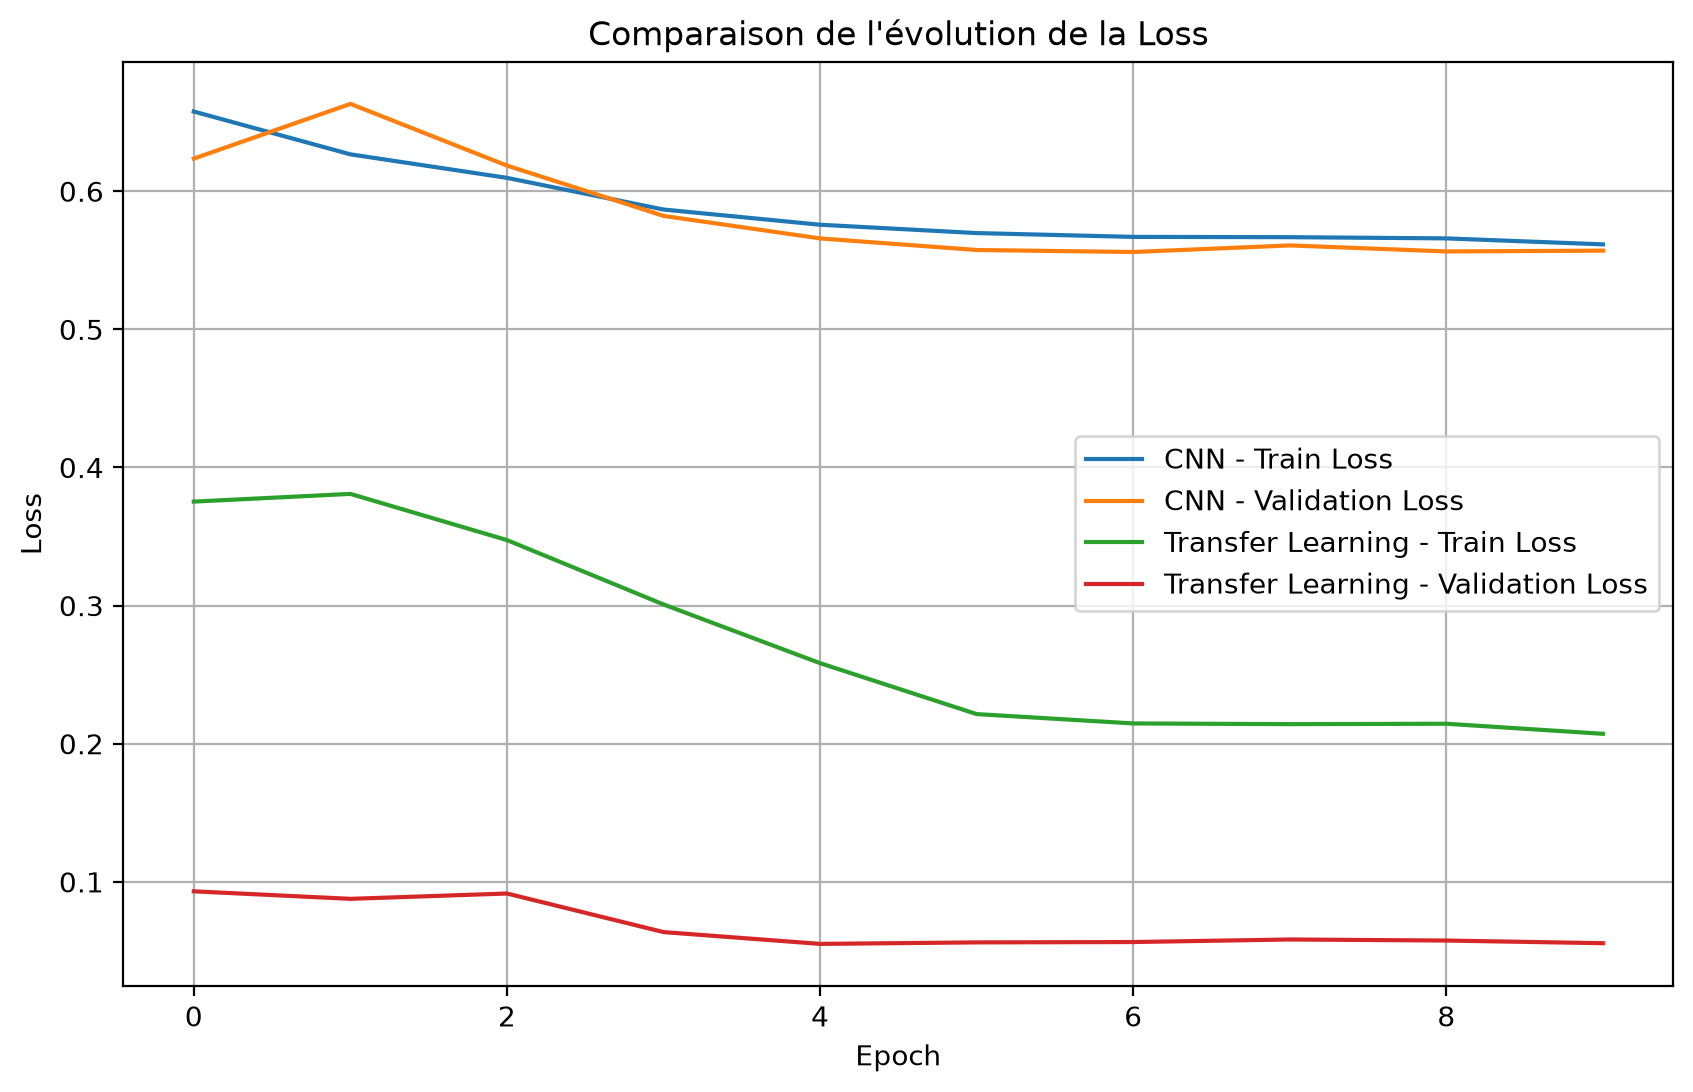

In [34]:
# Courbe comparative des Loss
plt.figure(figsize=(10, 6))

# CNN from scratch
plt.plot(history_adam_cnn["train_loss"], label="CNN - Train Loss")
plt.plot(history_adam_cnn["val_loss"], label="CNN - Validation Loss")

# Transfer Learning
plt.plot(history_sgd_tl["train_loss"], label="Transfer Learning - Train Loss")
plt.plot(history_sgd_tl["val_loss"], label="Transfer Learning - Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparaison de l'évolution de la Loss")

plt.legend()
plt.grid(True)

plt.show()

# courbes de l'accuracy

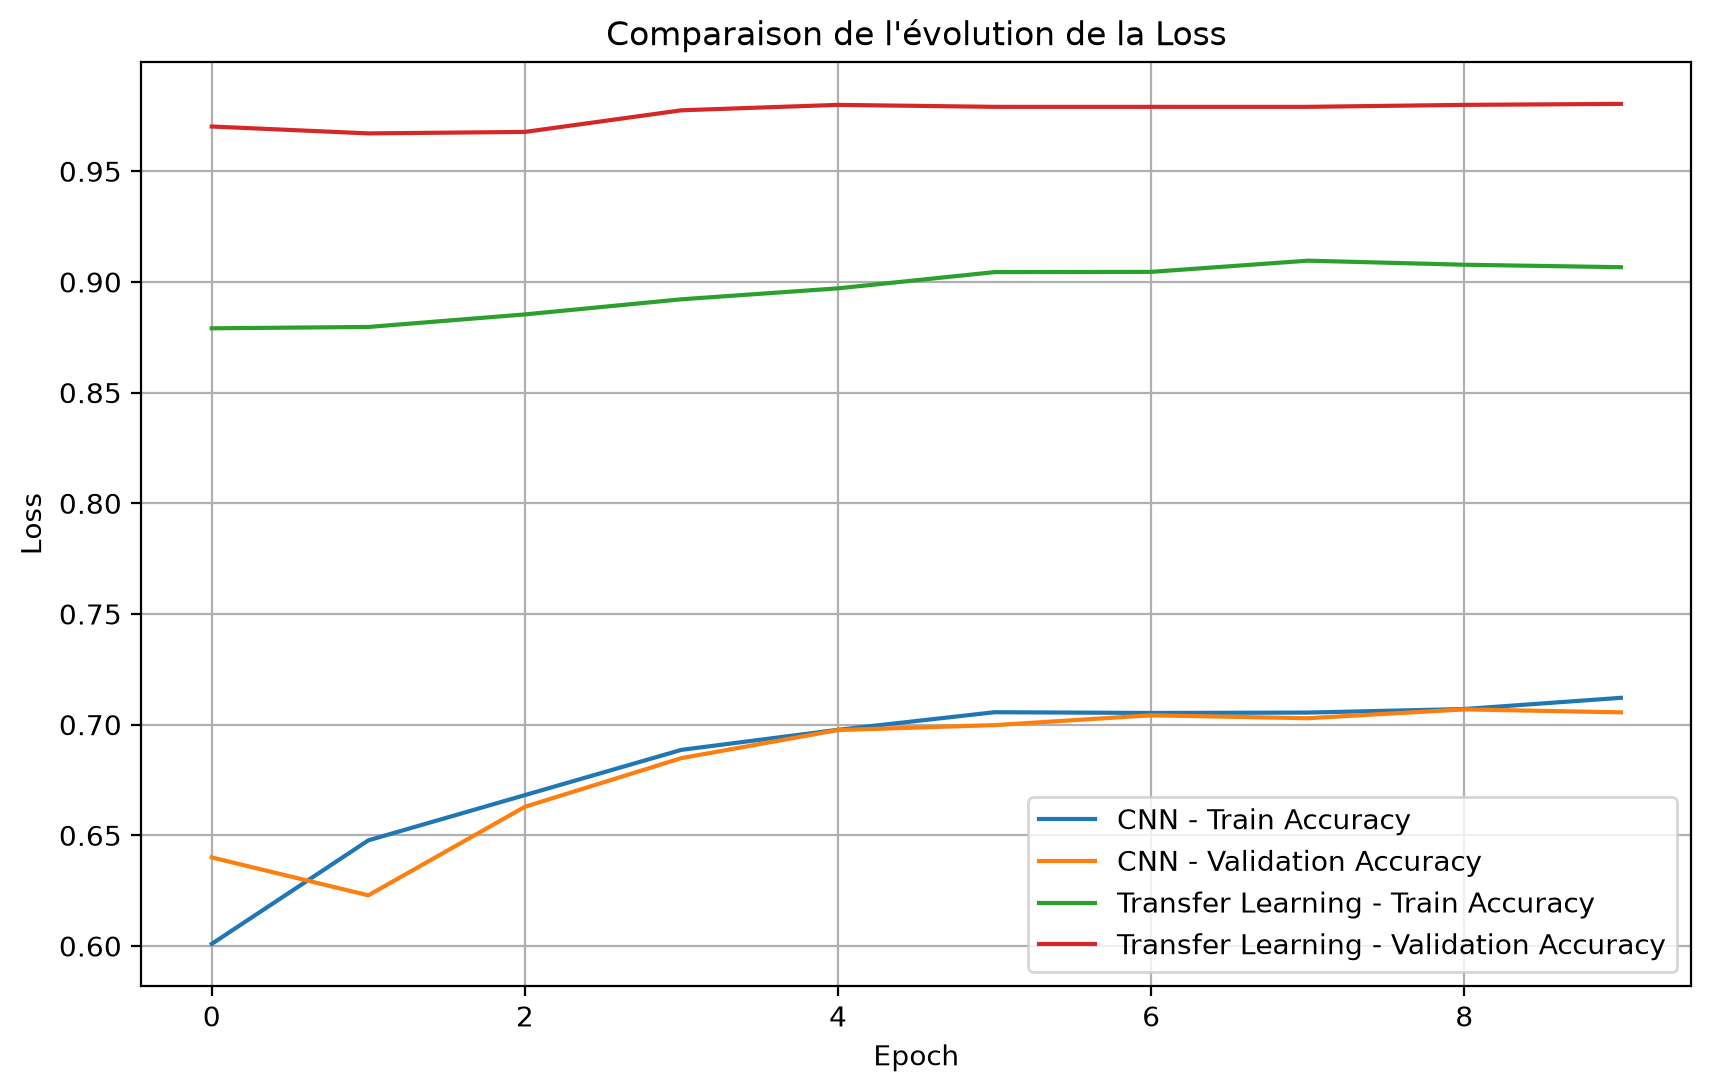

In [35]:
# Courbe comparative des Loss
plt.figure(figsize=(10, 6))

# CNN from scratch
plt.plot(history_adam_cnn["train_accuracy"], label="CNN - Train Accuracy")
plt.plot(history_adam_cnn["val_accuracy"], label="CNN - Validation Accuracy")

# Transfer Learning
plt.plot(history_sgd_tl["train_accuracy"], label="Transfer Learning - Train Accuracy")
plt.plot(history_sgd_tl["val_accuracy"], label="Transfer Learning - Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparaison de l'évolution de la Loss")

plt.legend()
plt.grid(True)

plt.show()

La comparaison entre le modèle CNN entraîné from scratch et le modèle en transfert d’apprentissage met en évidence un écart important de performance en faveur du transfert d’apprentissage.

Pour le CNN from scratch, Adam est retenu comme optimiseur. Le modèle atteint une accuracy maximale de 70,69 % sur l’ensemble de validation, avec une précision de 68,75 % et un rappel de 75,55 %. La loss de validation atteint 0,5570 à la 10ᵉ époque. Ces résultats montrent que le modèle apprend progressivement les caractéristiques des images, mais que ses performances restent limitées après 10 époques d’entraînement.

Pour le modèle en transfert d’apprentissage, SGD est retenu. Le modèle atteint une accuracy maximale de 98,04 % sur l’ensemble de validation, une précision maximale de 97,96 % et une loss minimale de 0,0551. Le rappel maximal obtenu avec Adam atteint 99,16 %. Les performances obtenues sont donc nettement supérieures à celles du CNN from scratch.

L’écart d’accuracy entre les deux approches est particulièrement important : 98,04 % pour le transfert learning contre 70,69 % pour le CNN from scratch, soit une différence de 27,35 points de pourcentage. La loss est également beaucoup plus faible avec le transfert learning, ce qui traduit une meilleure capacité du modèle à effectuer la classification.

En termes de convergence, le transfert learning présente également un avantage important. Dès la première époque, il atteint une accuracy de validation de 97,02 % avec SGD, alors que le CNN from scratch atteint 64,00 % avec Adam. Le modèle pré-entraîné dispose déjà de représentations visuelles pertinentes, ce qui lui permet d’apprendre beaucoup plus rapidement que le CNN entraîné entièrement à partir de zéro.

En conclusion, dans cette expérimentation, le transfert d’apprentissage permet une convergence plus rapide et des performances de validation nettement supérieures au CNN from scratch. Il apparaît ainsi particulièrement efficace pour la classification des images de chats et de chiens, grâce à l’exploitation de représentations déjà apprises sur de grandes bases d’images.


Comparaison des deux approches

La comparaison entre le modèle CNN entraîné from scratch et le modèle en transfert d’apprentissage met en évidence un écart important de performance en faveur du transfert d’apprentissage.

Pour le CNN from scratch, Adam est retenu comme optimiseur. Le modèle atteint une accuracy maximale de 70,69 % sur l’ensemble de validation, avec une précision de 68,75 % et un rappel de 75,55 % à la 10ᵉ époque. La loss de validation à cette même époque est de 0,5570. Ces résultats montrent que le modèle apprend progressivement les caractéristiques des images, mais ses performances restent relativement limitées après 10 époques.

Pour le modèle en transfert d’apprentissage, SGD est retenu. Le modèle atteint une accuracy maximale de 98,04 % sur l’ensemble de validation, avec une précision maximale de 97,96 % et une loss minimale de 0,0551. Le rappel maximal obtenu avec Adam atteint 99,16 %. Le transfert d’apprentissage permet donc d'obtenir des performances nettement supérieures au CNN from scratch sur l'ensemble de validation.

L'écart d'accuracy entre les deux approches est particulièrement important : 98,04 % pour le transfert learning contre 70,69 % pour le CNN from scratch, soit environ 27,35 points de pourcentage. La loss est également beaucoup plus faible avec le transfert learning, ce qui traduit des prédictions plus confiantes et une meilleure capacité à distinguer les deux classes.

Sur l'ensemble de test, le modèle Transfer Learning retenu obtient une accuracy de 90,56 %, une précision de 96,94 %, un rappel de 83,76 % et une loss de 0,2076. Comparativement aux performances obtenues en validation, la baisse de l'accuracy et l'augmentation de la loss montrent que le modèle est moins performant sur les données de test, mais sa précision reste élevée.

En termes de convergence, le transfert learning présente également un avantage important. Dès la première époque, il atteint environ 97,02 % d'accuracy en validation avec SGD, alors que le CNN from scratch atteint 64,00 % avec Adam. Cela montre que les connaissances déjà acquises par le modèle pré-entraîné permettent d'identifier rapidement les caractéristiques pertinentes des images, contrairement au CNN from scratch qui doit apprendre ces représentations à partir de zéro.

En conclusion, dans cette expérimentation, le transfert d'apprentissage améliore fortement la convergence et les performances du modèle par rapport à un CNN entraîné from scratch. Il permet d'obtenir une meilleure accuracy, une loss plus faible et une précision nettement supérieure. Toutefois, l'écart entre les performances de validation et de test montre qu'il est également nécessaire d'évaluer la robustesse du modèle sur des données totalement indépendantes.


# chargement du meilleur modéle

In [29]:
# ============================================================
# CHARGEMENT DU MEILLEUR MODÈLE
# ============================================================

best_checkpoint = torch.load(
    best_path_sgd,
    map_location=device
)

model_tl_sgd.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model_tl_sgd.to(device)

model_tl_sgd.eval()

print(
    "Meilleure Val Accuracy :",
    f"{best_checkpoint['best_val_accuracy']:.4f}"
)

Meilleure Val Accuracy : 0.9804


# Test Transfert learning

In [30]:
# ============================================================
# TEST FINAL
# ============================================================

test_loss = 0.0

test_predictions = []
test_labels = []

with torch.inference_mode():

    for images, labels in tqdm(
        testloader,
        desc="Test final"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model_tl_sgd(images)

        loss = criterion_tl(
            outputs,
            labels
        )

        test_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(1)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

test_loss /= len(test_data)

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)

c:\Users\Moustapha MBENGUE\OneDrive\Desktop\MASTER_IA_DIT\DEVOIR_DEEP_LEARNING\env_dev_deep_learning\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test final:   0%|          | 0/79 [00:00<?, ?it/s]

# Métriques d'évaluation

In [31]:
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)

print("===== TEST FINAL =====")
print("Loss      :", test_loss)
print("Accuracy  :", test_accuracy)
print("Precision :", test_precision)
print("Recall    :", test_recall)

===== TEST FINAL =====
Loss      : 0.20755490235090257
Accuracy  : 0.9056
Precision : 0.9694444444444444
Recall    : 0.8376


Sur l'ensemble de test, le modèle Transfer Learning retenu obtient une accuracy de 90,56 %, une précision de 96,94 %, un rappel de 83,76 % et une loss de 0,2076. Comparativement aux performances obtenues en validation, la baisse de l'accuracy et l'augmentation de la loss montrent que le modèle est moins performant sur les données de test, mais sa précision reste élevée.

# matrice de confusion

In [32]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

print(cm)

[[1217   33]
 [ 203 1047]]


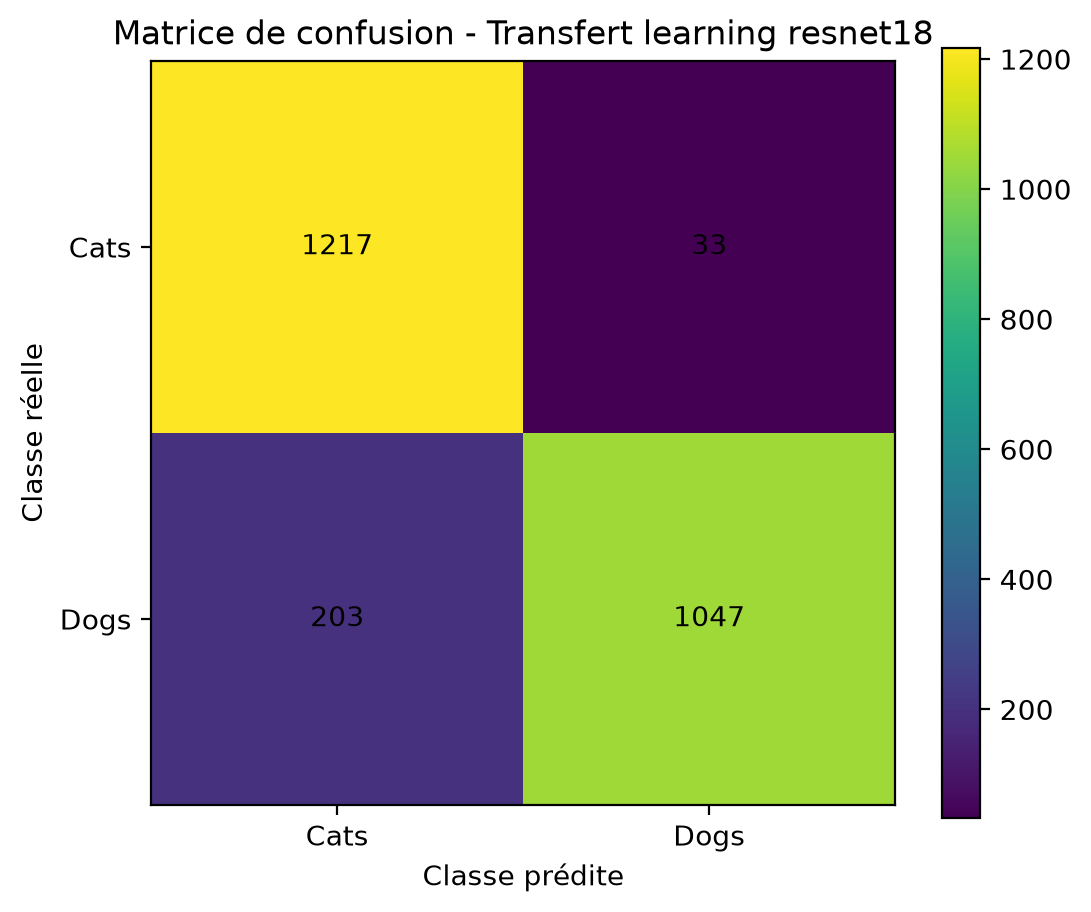

In [33]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Matrice de confusion - Transfert learning resnet18")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")

plt.xticks([0, 1], ["Cats", "Dogs"])
plt.yticks([0, 1], ["Cats", "Dogs"])

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

D'apres la matrice de confusion sur les 1250 images tests de chiens, 1047 ont ete bien classé par le modele soit un rappel de 83,76% et sur les 1250 images tests de chats 1217 ont été bien classé par le modéle soit un rappel de 97,36%. 

Sur les 1420 images de chats prédites par le modéle 808 ont été bien prédit soit une précision de 85,70% et sr les 1080 images de chiens prédies par le modéle 1047 ont été bien prédit par le modéle soit une précision de 96,94%. 



# tableau de comparaison

# TP – CNN “from scratch” vs Transfert Learning (Cats vs Dogs)

## Objectif

Comparer **un modèle CNN entraîné from scratch** et **un modèle en transfert d’apprentissage** sur le même jeu de données (cats vs dogs). Montrer l’impact du transfert learning sur la convergence, la performance et la robustesse.

## Ce qui est **obligatoire**

1. **Deux expériences distinctes**

   * Expérience A : CNN **from scratch** (architecture simple minimum 3 bloc avec conv).
   * Expérience B : **Transfert learning** (ex. ResNet, MobileNet, EfficientNet…), couches finales adaptées.
2. **Bonnes pratiques de régularisation**

   * Utiliser **Dropout** ET **Batch Normalization** (justifier où et pourquoi).
3. **Suivi des métriques**

   * **Training loss**, **Accuracy**, **Précision**, **Recall** à chaque époque (et idéalement sur train/val si vous faites une validation).
   * Tracer des **courbes** et **comparer** les deux approches.
4. **Optimisation**

   * Tester au moins **2 optimiseurs** (ex. SGD et Adam).
   * Chercher un **bon learning rate** (essais ou scheduler).
5. **GPU**

   * Entraîner **sur GPU** si disponible (vérification et mention dans README).
6. **Persistance du modèle**

   * **Sauvegarder** le meilleur modèle (.pt/.pth) localement (ne **pas** pousser dans GitHub).
   * **Recharger** le modèle pour faire le **test final** et rapporter les métriques.
7. **Reproductibilité**

   * Fixer un **seed**

## Ce qui est **souhaité (bonus)**

* **Split train/validation** (clair et justifié).
* **Data augmentation** raisonnable.
* **Scheduler** (ex. StepLR, CosineAnnealingLR).
* **Matrice de confusion** et quelques **erreurs typiques** commentées.
* Journalisation (TensorBoard/W&B) — sans pousser les fichiers lourds.

## Données

* Utilisez le même corpus **Cats vs Dogs** que vu en cours (ou équivalent).
* Ne **poussez pas** les données sur GitHub. Indiquez seulement **comment** les télécharger/placer.

## Structure du dépôt GitHub (exemple)

```
cnn-catsdogs-<NomPrenom>/
├─ notebook.ipynb
├─ .gitignore
├─ requirements.txt (ou environment.yml)
├─ README.md
└─ LICENSE (optionnel)
```

### `.gitignore` (minimum)

```
data/
*.pt
*.pth
runs/
checkpoints/
```

## Contenu attendu du **README.md**

* **Titre & objectif** du projet.
* **Environnement** ( `pip install -r requirements.txt` ou `conda env create -f environment.yml`).
* **Organisation des données** (où télécharger, où placer les dossiers).
* **Commandes pour entraîner** :

  * From scratch : arguments clés (batch size, lr, epochs, optimiser, dropout, BN, scheduler…).
  * Transfert learning : même chose + quelle base (gel des couches ou fine-tuning).
* **Commandes pour évaluer / recharger le modèle** (chemin du checkpoint local).
* **Résultats** : tableaux + courbes (loss/accuracy/précision/recall) pour les deux expériences, **comparaison et analyse** (2–3 paragraphes).
* **Limites & pistes d’amélioration** (brèves).

## Évaluation (grille indicative)

* Rigueur expérimentale & métriques (30 %)
* Qualité des modèles & optimisation (25 %)
* Clarté du code & structure du dépôt (20 %)
* README (reproductibilité, analyse, figures) (20 %)
* Bonus (val split, augmentation, scheduler, confusion matrix) (5 %)

## Remise
* ** FAIRE une vidéo de 05 à 10 minute pour expliquer votre travail"
* Envoyez **le lien du dépôt** à **[diallomous@gmail.com](mailto:diallomous@gmail.com)**
* **Date limite : jeud   avant 23h00. (Africa/Dakar).**

> Rappel :  Assurez-vous que votre dépôt permet de **reproduire** les expériences via les instructions du README.
